In [229]:
import numpy as np
from matplotlib import rc
rc('font', **{'family': 'serif', 'serif': ['Helvetica'], 'size': 10})
rc('text', usetex=True)

g = 1.
v = 1.
t = 0.

def ky(omega):
    return np.sqrt(omega**4 / g**4 - omega**2 / v**2)
def ky0(omega):
    return np.sqrt(omega**2 / v**2 - omega**4 / g**4)
def ff(omega):
    return np.exp(-omega**2 * v / g)

def wakeXY(x, y):
    omegas1 = np.linspace(0, g / v, 1000)
    omegas2 = np.linspace(g / v, 10 * g / v, 1000)
    func2 = lambda omega: ff(omega) * np.cos(omega * (t - x / v) - ky(omega) * np.abs(y))
    func1 = lambda omega: ff(omega) * np.cos(omega * (t - x / v)) * np.exp(-ky0(omega) * np.abs(y))
    return np.trapz(func1(omegas1), omegas1) + np.trapz(func2(omegas2), omegas2)

In [230]:
X = np.arange(-100, 10, .2)
Y = np.arange(-50, 50, .2)
Z = np.array([[wakeXY(x, y) for y in Y] for x in X])

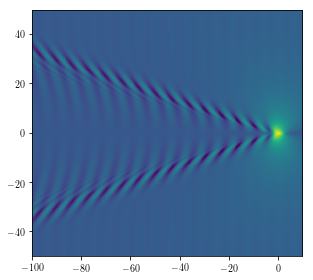

In [245]:
import matplotlib as mpl
import matplotlib.pyplot as plt
extent = np.min(X), np.max(X), np.min(Y), np.max(Y)
%matplotlib inline
Z = np.transpose(Z)
# Z = np.rot90(Z)
plt.imshow(Z+.3, extent=extent, cmap='viridis', norm=mpl.colors.LogNorm())
plt.tight_layout()
plt.savefig('/Users/hayk/Desktop/pic2.png', dpi=300)

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
rc('font', **{'family': 'serif', 'serif': ['Helvetica'], 'size': 10})
rc('text', usetex=True)

def circle(ax, x, y, radius=0.15, color='k', ls='-'):
    from matplotlib.patches import Circle
    from matplotlib.patheffects import withStroke
    circle = Circle((x, y), radius, clip_on=False, zorder=10, linewidth=0.2, linestyle='--',
                    edgecolor=color, facecolor=(0, 0, 0, 0),
                    path_effects=[withStroke(linewidth=1, foreground='w')])
    ax.add_artist(circle)

In [48]:
%matplotlib widget

plt.figure(figsize=(10,5))
ax = plt.gca()

ax.plot([-100, 0], [0, 0], c='k', lw=1)
ax.plot([-150, 50], [0, 0], c='k', ls='--', lw=1)

distance = 10
xs = np.arange(-100, 1, distance)
colors = plt.cm.viridis(np.linspace(0,1,len(xs)))
ax.scatter(xs, xs*0, c=colors, zorder=10, s=10)
alpha = 1.2
for i in np.arange(len(np.arange(-100, 1, distance))):
    circle(ax, xs[::-1][i], 0, radius = i * distance / alpha, color = colors[::-1][i])

ffy = (2 * alpha**2 - 1) / np.sqrt(alpha**2 - 1)
ax.plot(xs, xs / ffy, c='red')
ax.plot(xs, -xs / ffy, c='red')
    
ax.set_xlim(-120, 20)
ax.set_ylim(-50, 50)
ax.set_aspect(1)

FigureCanvasNbAgg()

In [100]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
rc('font', **{'family': 'serif', 'serif': ['Helvetica'], 'size': 10})
rc('text', usetex=True)
plt.style.use(['fivethirtyeight'])


def circle(ax, x, y, radius=0.15, color='k', ls='-', alpha=1):
    from matplotlib.patches import Circle
    from matplotlib.patheffects import withStroke
    color[-1] = alpha
    circle = Circle((x, y), radius, clip_on=False, zorder=10, linewidth=.5, linestyle=ls,
                    edgecolor=color, facecolor=(0, 0, 0, 0))
    ax.add_artist(circle)

%matplotlib widget

plt.figure(figsize=(10,5))
ax = plt.gca()

# ax.plot([-100, 0], [0, 0], c='k', lw=1)
ax.plot([-150, 50], [0, 0], c='k', ls='--', lw=1)

distance = 30
xs = np.arange(-100, 1, distance)
colors = plt.cm.plasma(np.linspace(0,1,len(xs)))
ax.scatter(xs, xs*0, c=colors, zorder=10, s=30)
alpha = 2.3
for i in np.arange(len(np.arange(-100, 1, distance))):
    circle(ax, xs[::-1][i], 0, radius = i * distance / alpha, 
           color = colors[::-1][i], ls='--')
    circle(ax, xs[::-1][i], 0, radius = i * distance / alpha / 2., 
           color = colors[::-1][i])

ax.axis('off')
ax.set_xlim(-150, 20)
ax.set_ylim(-50, 50)
ax.set_aspect(1)

FigureCanvasNbAgg()

<IPython.core.display.Javascript object>


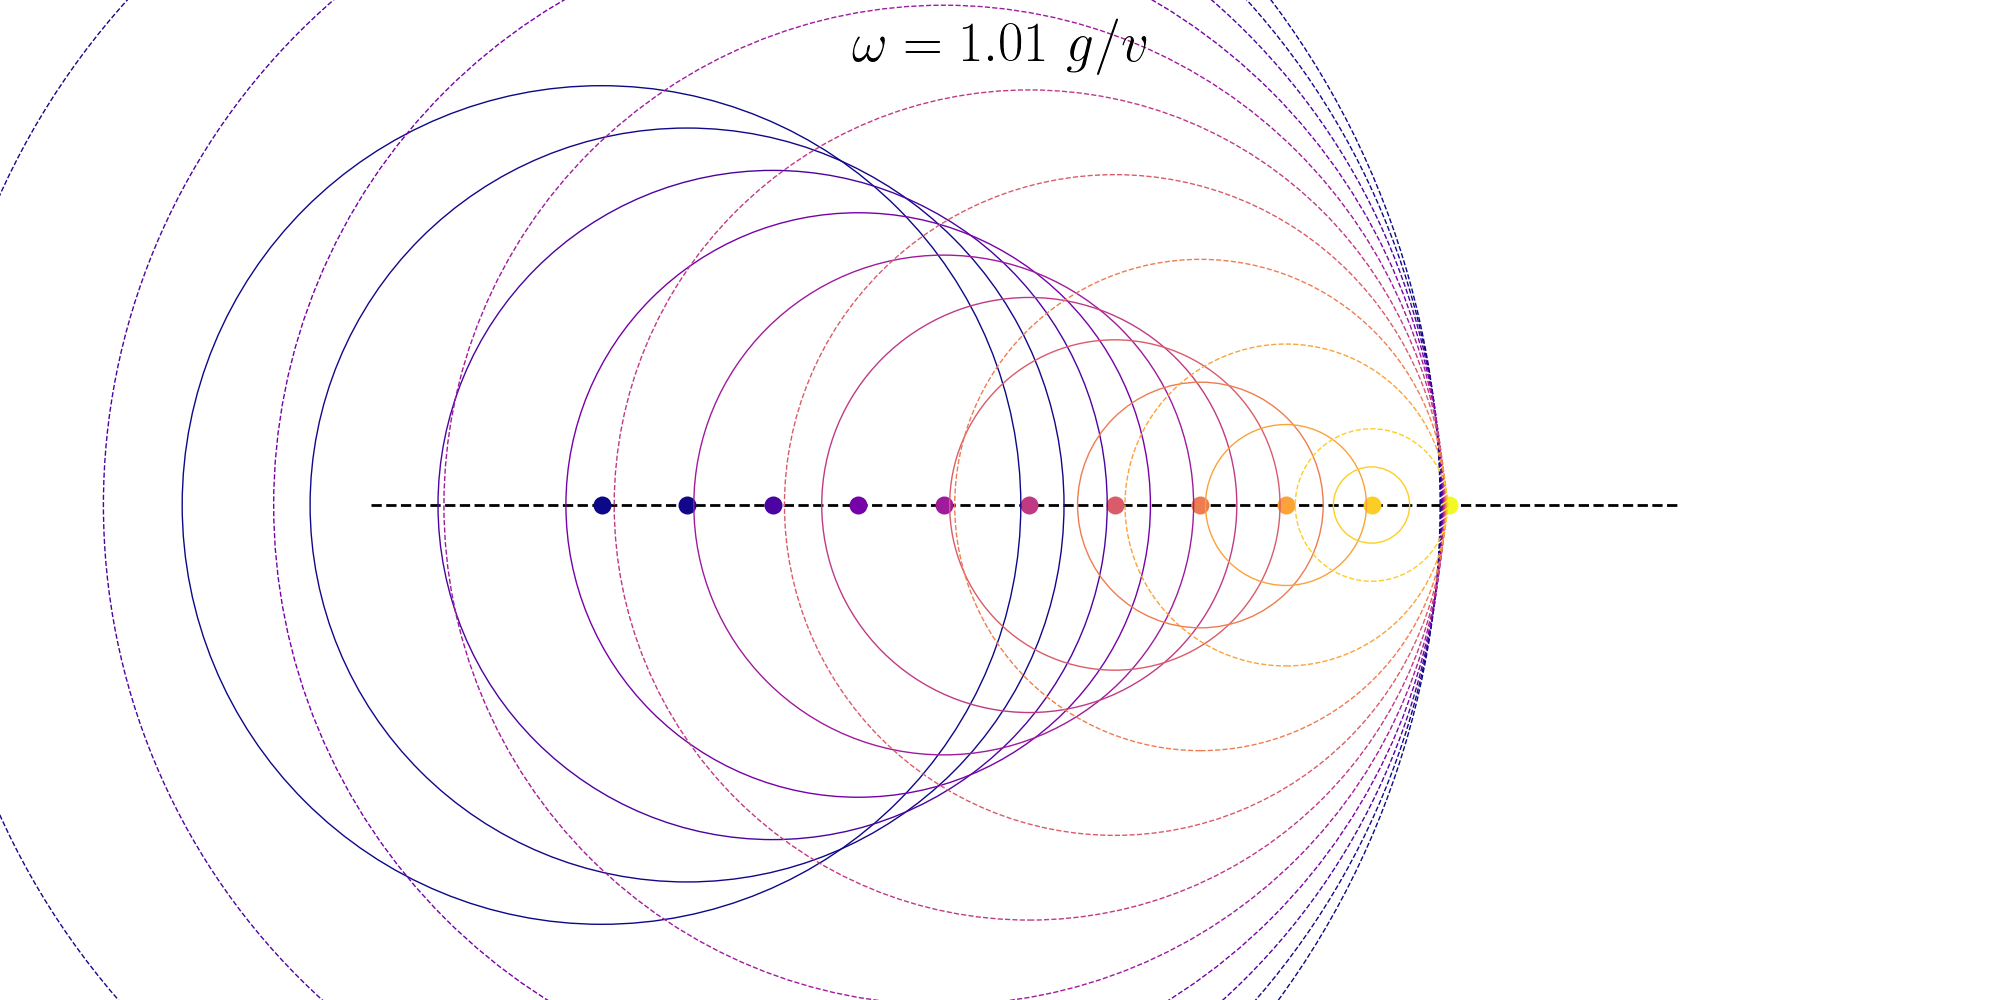

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
from IPython.html.widgets import *
rc('font', **{'family': 'serif', 'serif': ['Helvetica'], 'size': 10})
rc('text', usetex=True)
# plt.style.use(['fivethirtyeight'])

def circle(ax, x, y, radius=0.15, color='k', ls='-'):
    from matplotlib.patches import Circle
    from matplotlib.patheffects import withStroke
    circle = Circle((x, y), radius, clip_on=False, zorder=10, linewidth=.5, linestyle=ls,
                    edgecolor=color, facecolor=(0, 0, 0, 0))
    ax.add_artist(circle)

%matplotlib notebook

plt.figure(figsize=(10,5))

plt.gca().axis('off')
plt.xlim(-150, 20)
plt.ylim(-50, 50)
plt.gca().set_aspect(1)
plt.suptitle(r'$\omega={{{}}}~g/v$'.format(str(alpha)), fontsize=20)
v = 100
plt.plot([-150, 50], [0, 0], c='k', ls='--', lw=1)

cmap = plt.cm.plasma
plt.scatter(-120 + v * time, 0, c=cmap(255), zorder=10, s=30)

times = np.linspace(0, 1, 10)
vph = v / alpha
vgr = vph / 2.
circles = []
for tm in times:
    if time > tm:
        plt.scatter(-120 + v * tm, 0, c=cmap(1 - time + tm), zorder=10, s=30)
        circle(plt.gca(), -120 + v * tm, 0, radius = vph * (time - tm), 
               color = cmap(1 - time + tm), ls='--')
        circle(plt.gca(), -120 + v * tm, 0, radius = vgr * (time - tm), 
               color = cmap(1 - time + tm))

# def draw(tt, alpha):
#     def draw_t(time):
        
#     draw_t(tt)
alpha = 1.01
draw(1.1, alpha)

<IPython.core.display.Javascript object>


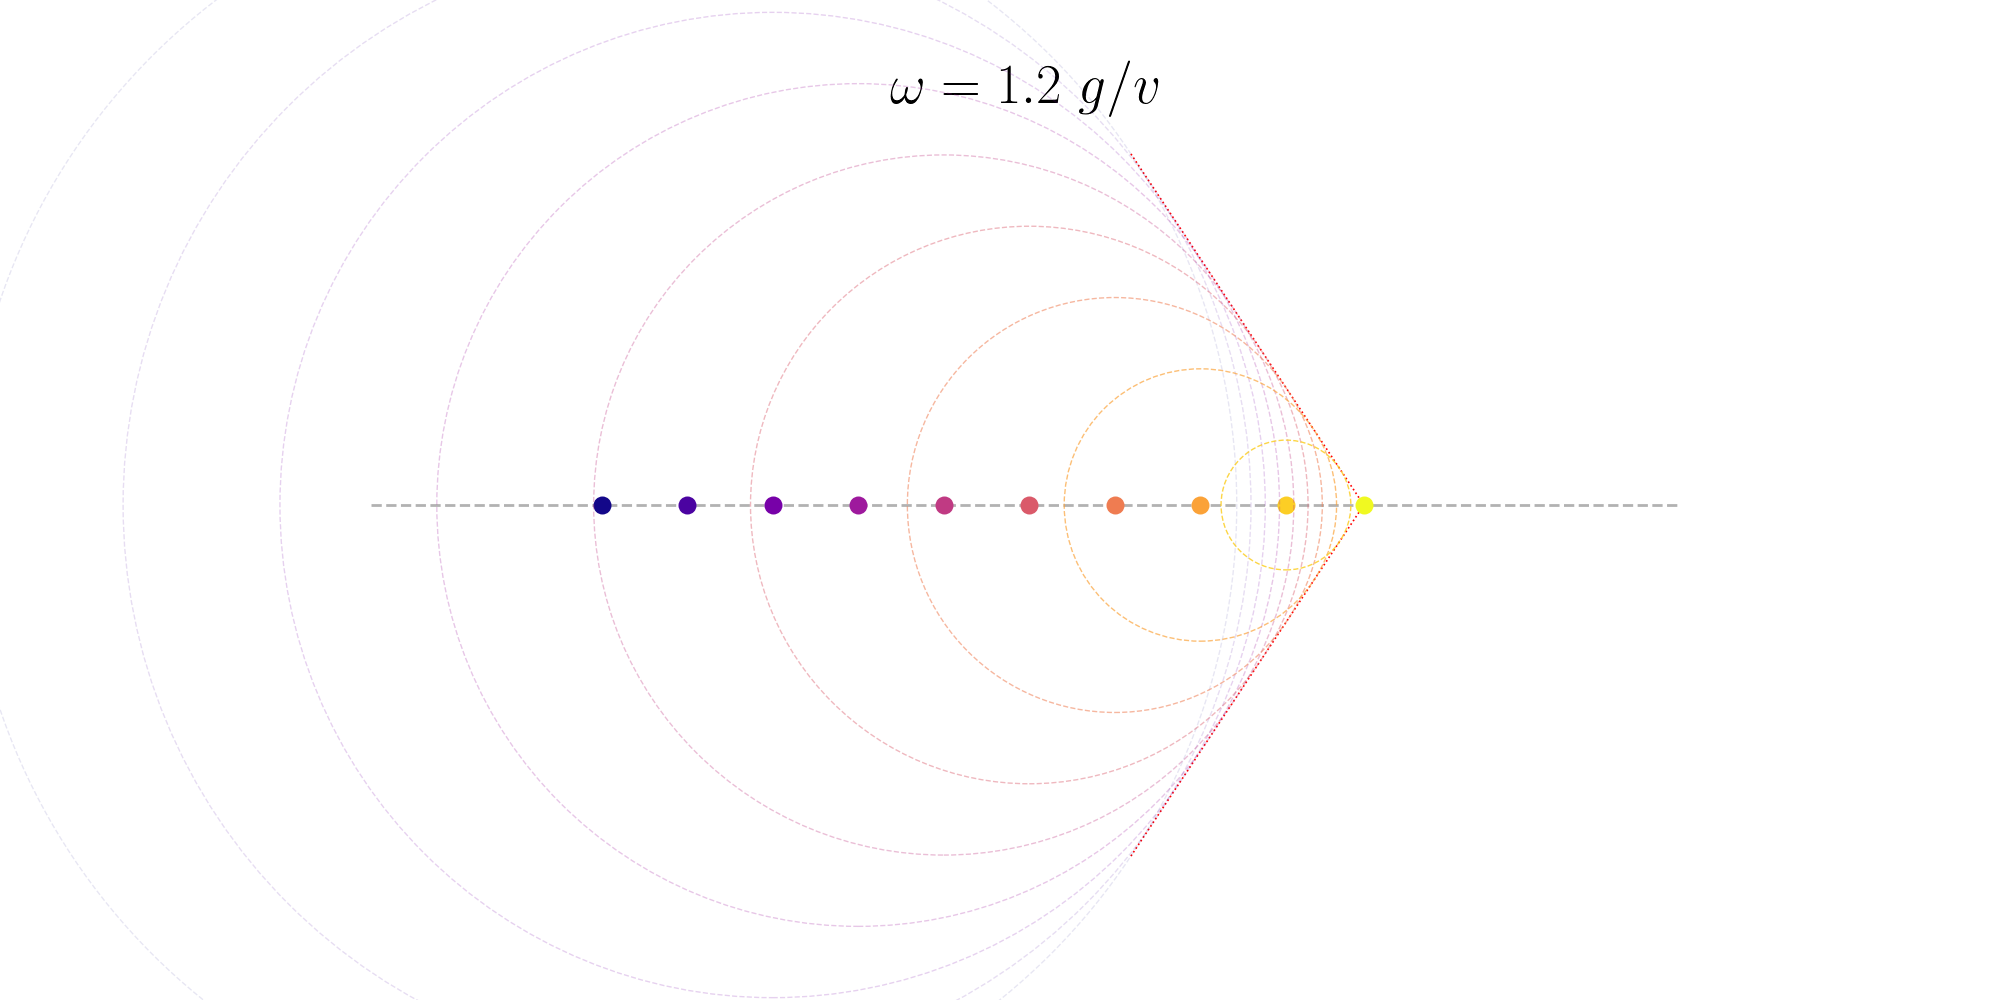

In [170]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation, rc
from matplotlib.patches import Circle
from IPython.display import HTML, Image
rc('font', **{'family': 'serif', 'serif': ['Helvetica'], 'size': 10})
rc('text', usetex=True)
%matplotlib notebook

v = 100.
cmap = plt.cm.plasma
times = np.linspace(0, 1, 10)
alpha = 1.2
vph = v / alpha
vgr = vph / 2.

def circle(ax, x, y, radius=0.15, color='k', ls='-'):
    circle = Circle((x, y), radius, clip_on=False, zorder=10, linewidth=.5, linestyle=ls)
    ax.add_artist(circle)
    return circle

fig, ax = plt.subplots(figsize=(10,5))
ax.axis('off')
ax.set_xlim(-150, 20)
ax.set_ylim(-50, 50)
ax.set_aspect(1)
ax.plot([-150, 50], [0, 0], c='k', ls='--', lw=1, alpha=0.3)
ax.set_title(r'$\omega={{{}}}~g/v$'.format(str(alpha)), fontsize=20)
pnt = ax.scatter(-10000, 0, c=cmap(255), zorder=10, s=30)
pnts = []
circles1 = []
# circles2 = []
for tm in times:
    pnts.append(plt.scatter(-10000, 0, zorder=10, s=30))
    circ = circle(ax, 0, 0, radius=0, ls='--')
    circ.set_visible(False)
    circles1.append(circ)
#     circ = circle(ax, 0, 0, radius=0)
#     circ.set_visible(False)
#     circles2.append(circ)

line1, = ax.plot([], [], c='red', lw=0.6, ls=':')
line2, = ax.plot([], [], c='red', lw=0.6, ls=':')
    
def animate(i):
    time = i / 100.
    pnt.set_offsets(np.c_[-120 + v * time, 0])
    for i in range(len(times)):
        if time > times[i]:
            pnts[i].set_facecolors(cmap(1 - time + times[i]))
            pnts[i].set_offsets(np.c_[-120 + v * times[i], 0])
            # phase
            circles1[i].center = -120 + v * times[i], 0
            circles1[i].radius = vph * (time - times[i])
            col = list(cmap(1 - time + times[i]))
            col[-1] = 1 - np.tanh(1.5 * (time - times[i]))
            col = tuple(col)
            circles1[i].set_edgecolor(col)
            circles1[i].set_facecolor((0,0,0,0))
            circles1[i].set_visible(True)
            
            #group
#             circles2[i].center = -120 + v * times[i], 0
#             circles2[i].radius = vgr * (time - times[i])
#             circles2[i].set_edgecolor(cmap(1 - time + times[i]))
#             circles2[i].set_facecolor((0,0,0,0))
#             circles2[i].set_visible(True)
            
        #line
        t = (time - times[0])
        xs = np.array([-120 + v * time, -120 + v * time - v * t + vph**2 * t / v])
        ys = np.array([0, (vph / v) * np.sqrt(v**2 - vph**2) * t])
        line1.set_xdata(xs)
        line1.set_ydata(ys)
        line2.set_xdata(xs)
        line2.set_ydata(-ys)
    
anim = animation.FuncAnimation(fig, animate, np.arange(0, 100, .3 * 10), interval=1, repeat=False)
anim.save('/Users/hayk/Desktop/anim1.gif', writer='imagemagick', fps=6)
# anim = animation.FuncAnimation(fig, animate, np.arange(0,100,2), interval=1, repeat=False)
# anim.save('/Users/hayk/Desktop/animation.gif', writer='imagemagick', fps=30)

<IPython.core.display.Javascript object>


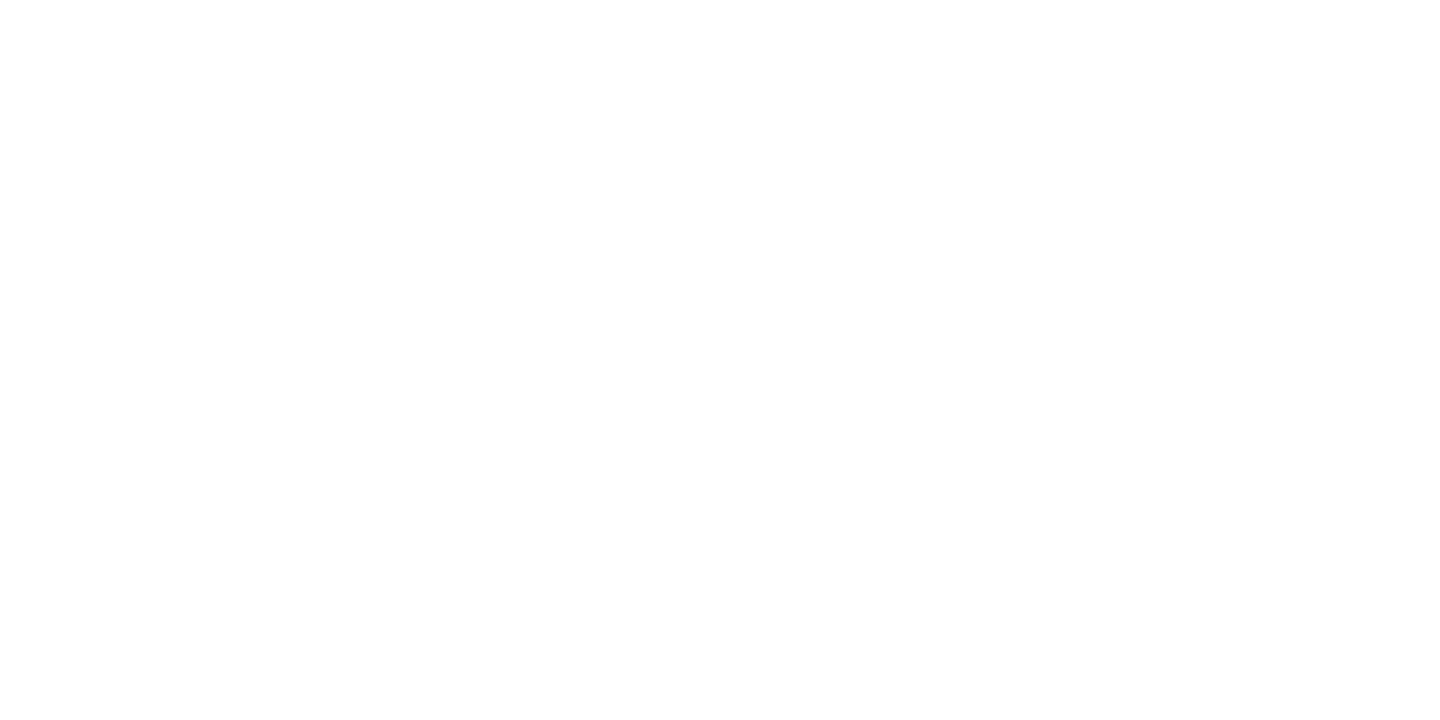

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


<IPython.core.display.Javascript object>


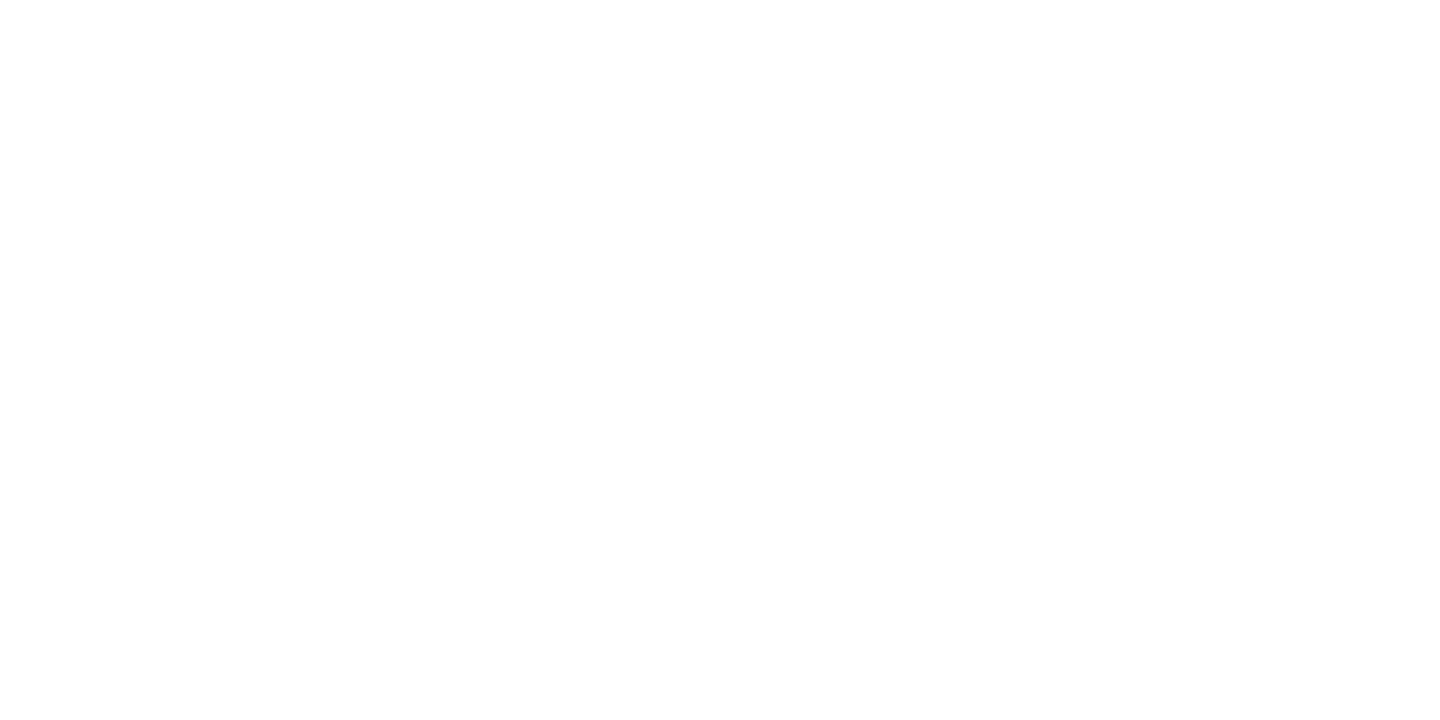

Traceback (most recent call last):
  File "/Users/hayk/anaconda/envs/py36/lib/python3.6/site-packages/matplotlib/cbook/__init__.py", line 388, in process
    proxy(*args, **kwargs)
  File "/Users/hayk/anaconda/envs/py36/lib/python3.6/site-packages/matplotlib/cbook/__init__.py", line 228, in __call__
    return mtd(*args, **kwargs)
  File "/Users/hayk/anaconda/envs/py36/lib/python3.6/site-packages/matplotlib/animation.py", line 1499, in _stop
    self.event_source.remove_callback(self._loop_delay)
AttributeError: 'NoneType' object has no attribute 'remove_callback'


In [246]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation, rc
from __future__ import unicode_literals
from matplotlib.patches import Circle
from IPython.display import HTML, Image
rc('font', **{'family': 'serif', 'serif': ['Helvetica'], 'size': 10})
rc('text.latex',unicode=True)
rc('text.latex',preamble=r'\usepackage[utf8]{inputenc}')
rc('text.latex',preamble=r'\usepackage[russian]{babel}')
matplotlib.rcParams['text.latex.unicode'] = True
%matplotlib notebook

v = 100.
cmap = plt.cm.plasma
times = np.linspace(0, 1, 10)
alpha = 1.25
vph = v / alpha
vgr = vph / 2.

def circle(ax, x, y, radius=0.15, color='k', ls='-'):
    circle = Circle((x, y), radius, clip_on=False, zorder=10, linewidth=.5, linestyle=ls)
    ax.add_artist(circle)
    return circle

fig, ax = plt.subplots(figsize=(10,5))
ax.axis('off')
ax.set_xlim(-150, 20)
ax.set_ylim(-50, 50)
ax.set_aspect(1)
ax.plot([-150, 50], [0, 0], c='k', ls='--', lw=1, alpha=0.3)
# ax.set_title(r'$v_{\textrm{ф}}$' + r'$={{{:.1f}}}~v$'.format(1/alpha) + r'~~~$v_{\textrm{гр}}$' + r'$={{{:.1f}}}~v$'.format(0.5/alpha), fontsize=20)
pnt = ax.scatter(-10000, 0, c=cmap(255), zorder=10, s=30)
pnts = []
circles1 = []
lines1 = []
lines2 = []
pnts2 = []
# circles2 = []
for tm in times:
    pnts.append(plt.scatter(-10000, 0, zorder=10, s=30))
    circ = circle(ax, 0, 0, radius=0, ls='--')
    circ.set_visible(False)
    circles1.append(circ)
    ln1, = ax.plot([], [], c='red', lw=0.6)
    ln2, = ax.plot([], [], c='red', lw=0.6)
    lines1.append(ln1)
    lines2.append(ln2)
    pnts2.append(plt.scatter(-10000, 0, zorder=10, s=20))
#     circ = circle(ax, 0, 0, radius=0)
#     circ.set_visible(False)
#     circles2.append(circ)

line1, = ax.plot([], [], c='red', lw=0.6, ls=':')
line2, = ax.plot([], [], c='red', lw=0.6, ls=':')
text1 = ax.text(-1000, -1000, '', fontsize=15)
text2 = ax.text(-1000, -1000, '', fontsize=15)
line3, = ax.plot([], [], c='red', lw=0.6)
    
def animate(i):
    if i < 100:
        time = i / 100.
    else:
        time = 1.
    pnt.set_offsets(np.c_[-120 + v * time, 0])
    # phase front
    t = (time - times[0])
    x1 = -120. + v * time
    x2 = -120. + v * time - v * t + vph**2 * t / v
    y1 = 0.
    y2 = (vph / v) * np.sqrt(v**2 - vph**2) * t
    line1.set_xdata([x1, x2])
    line1.set_ydata([y1, y2])
    line2.set_xdata([x1, x2])
    line2.set_ydata([-y1, -y2])
    for i in range(len(times)):
        if time > times[i]:
            x0 = -120. + v * times[i]
            y0 = 0.
            col0 = cmap(1 - time + times[i])
            # point
            pnts[i].set_facecolors(col0)
            pnts[i].set_offsets(np.c_[x0, y0])
            # circles
            circles1[i].center = x0, y0
            circles1[i].radius = vph * (time - times[i])
            col = list(col0)
            col[-1] = 1 - np.tanh(4 * (time - times[i]))
            col = tuple(col)
            circles1[i].set_edgecolor(col)
            circles1[i].set_facecolor((0,0,0,0))
            circles1[i].set_visible(True)
            # lines to front
            col = list(col0)
            col[-1] = 1 - np.tanh(2 * (time - times[i]))
            col = tuple(col)
            x3 = (x0*(x1 - x2)**2 + (x2*(-y0 + y1) + x1*(y0 - y2))*(y1 - y2))/(x1**2 - 2*x1*x2 + x2**2 + (y1 - y2)**2)
            y3 = (x2**2*y1 + y0*y1**2 + x0*(x1 - x2)*(y1 - y2) + x1**2*y2 - 2*y0*y1*y2 + y0*y2**2 - x1*x2*(y1 + y2))/(x1**2 - 2*x1*x2 + x2**2 + (y1 - y2)**2)
            lines1[i].set_xdata([x0, x3])
            lines1[i].set_ydata([y0, y3])
            lines1[i].set_color(col)
            lines2[i].set_xdata([x0, x3])
            lines2[i].set_ydata([y0, -y3])
            lines2[i].set_color(col)
            col = list(col0)
            col[-1] = 1 - np.tanh((time - times[i]))
            col = tuple(col)
            pnts2[i].set_offsets(np.c_[0.5 * (x0 + x3), 0.5 * (y0 + y3)])
            pnts2[i].set_facecolors(col)
    if time == 1:
        text1.set_ha('center')
        text1.set_va('center')
        text1.set_position([(x1 + x2) * 0.5 + 2, (y1 + y2) * 0.5 + 2])
        text1.set_text('фазовый фронт')
        text1.set_rotation(np.arctan((y2 - y1) / (x2 - x1)) * 180 / np.pi)
        text1.set_color('red')
        
        x0 = -120.
        y0 = 0.
        x3 = (x0*(x1 - x2)**2 + (x2*(-y0 + y1) + x1*(y0 - y2))*(y1 - y2))/(x1**2 - 2*x1*x2 + x2**2 + (y1 - y2)**2)
        y3 = (x2**2*y1 + y0*y1**2 + x0*(x1 - x2)*(y1 - y2) + x1**2*y2 - 2*y0*y1*y2 + y0*y2**2 - x1*x2*(y1 + y2))/(x1**2 - 2*x1*x2 + x2**2 + (y1 - y2)**2)
        x2, y2 = (0.5 * (x0 + x3), 0.5 * (y0 + y3))
        
        text2.set_ha('center')
        text2.set_va('center')
        text2.set_position([0.5 * (x1 + x2) + 3, 0.5 * (y1 + y2) + 3])
        text2.set_text('групповой фронт')
        text2.set_rotation(np.arctan((y2 - y1) / (x2 - x1)) * 180 / np.pi)
        text2.set_color('red')

        line3.set_xdata([x1, x2])
        line3.set_ydata([y1, y2])
#     plt.tight_layout()

factor = 3
anim = animation.FuncAnimation(fig, animate, np.arange(0, 150, .3 * factor), interval=1, repeat=False)
anim.save('/Users/hayk/Desktop/anim2.gif', writer='imagemagick', fps=60 / factor, dpi=150)
# anim = animation.FuncAnimation(fig, animate, np.arange(0,100,2), interval=1, repeat=False)
# anim.save('/Users/hayk/Desktop/animation.gif', writer='imagemagick', fps=30)

<IPython.core.display.Javascript object>


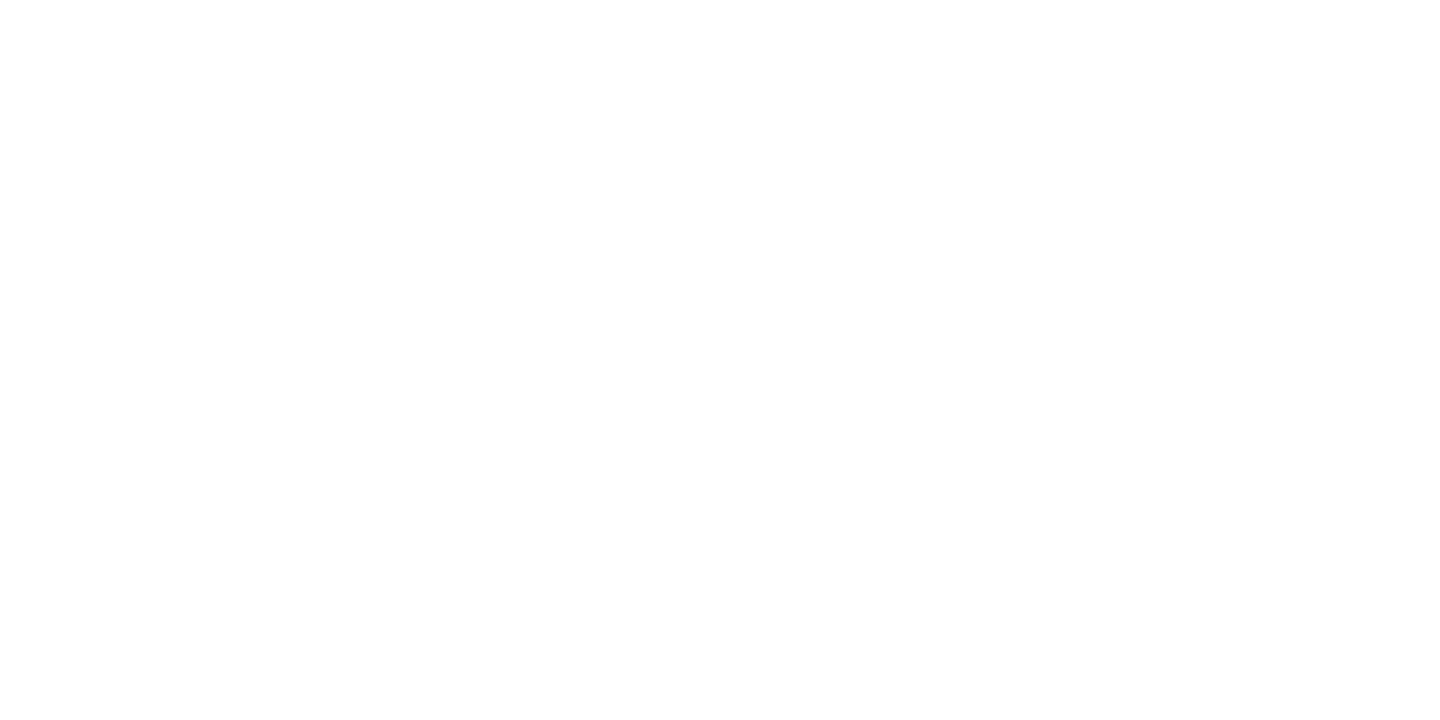

KeyboardInterrupt: 

<IPython.core.display.Javascript object>


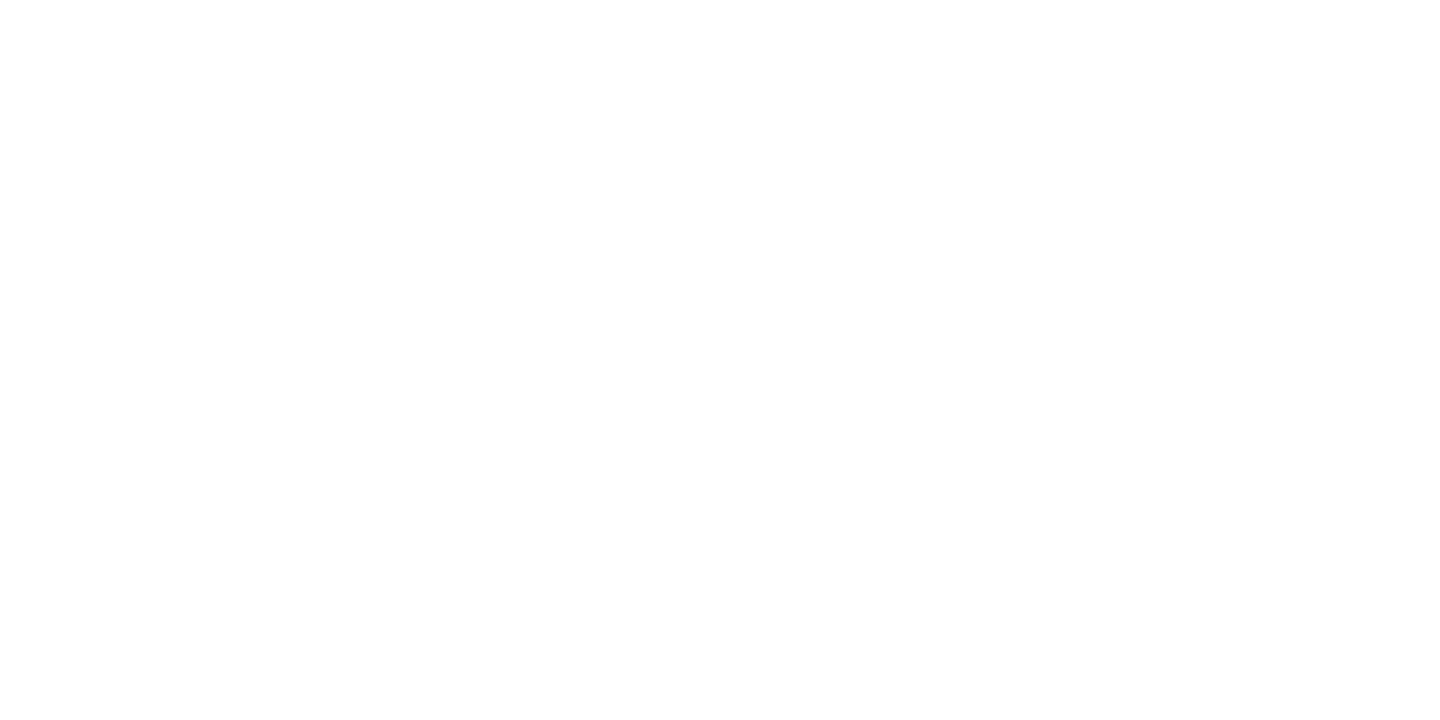

Traceback (most recent call last):
  File "/Users/hayk/anaconda/envs/py36/lib/python3.6/site-packages/matplotlib/cbook/__init__.py", line 388, in process
    proxy(*args, **kwargs)
  File "/Users/hayk/anaconda/envs/py36/lib/python3.6/site-packages/matplotlib/cbook/__init__.py", line 228, in __call__
    return mtd(*args, **kwargs)
  File "/Users/hayk/anaconda/envs/py36/lib/python3.6/site-packages/matplotlib/animation.py", line 1499, in _stop
    self.event_source.remove_callback(self._loop_delay)
AttributeError: 'NoneType' object has no attribute 'remove_callback'


In [247]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation, rc
from __future__ import unicode_literals
from matplotlib.patches import Circle
from IPython.display import HTML, Image
rc('font', **{'family': 'serif', 'serif': ['Helvetica'], 'size': 10})
rc('text.latex',unicode=True)
rc('text.latex',preamble=r'\usepackage[utf8]{inputenc}')
rc('text.latex',preamble=r'\usepackage[russian]{babel}')
matplotlib.rcParams['text.latex.unicode'] = True
%matplotlib notebook

v = 100.
cmap = plt.cm.plasma
times = np.linspace(0, 1, 10)
alpha = 1.25
vph = v / alpha
vgr = vph / 2.

def circle(ax, x, y, radius=0.15, color='k', ls='-'):
    circle = Circle((x, y), radius, clip_on=False, zorder=10, linewidth=.5, linestyle=ls)
    ax.add_artist(circle)
    return circle

fig, ax = plt.subplots(figsize=(10,5))
ax.axis('off')
ax.set_xlim(-150, 20)
ax.set_ylim(-50, 50)
ax.set_aspect(1)
ax.plot([-150, 50], [0, 0], c='k', ls='--', lw=1, alpha=0.3)
# ax.set_title(r'$v_{\textrm{ф}}$' + r'$={{{:.1f}}}~v$'.format(1/alpha) + r'~~~$v_{\textrm{гр}}$' + r'$={{{:.1f}}}~v$'.format(0.5/alpha), fontsize=20)
pnt = ax.scatter(-10000, 0, c=cmap(255), zorder=10, s=30)
pnts = []
circles1 = []
lines1 = []
lines2 = []
pnts2 = []
# circles2 = []
for tm in times:
    pnts.append(plt.scatter(-10000, 0, zorder=10, s=30))
    circ = circle(ax, 0, 0, radius=0, ls='--')
    circ.set_visible(False)
    circles1.append(circ)
#     ln1, = ax.plot([], [], c='red', lw=0.6)
#     ln2, = ax.plot([], [], c='red', lw=0.6)
#     lines1.append(ln1)
#     lines2.append(ln2)
#     pnts2.append(plt.scatter(-10000, 0, zorder=10, s=20))
#     circ = circle(ax, 0, 0, radius=0)
#     circ.set_visible(False)
#     circles2.append(circ)

line1, = ax.plot([], [], c='red', lw=0.6, ls=':')
line2, = ax.plot([], [], c='red', lw=0.6, ls=':')
text1 = ax.text(-1000, -1000, '', fontsize=15)
    
def animate(i):
    if i < 100:
        time = i / 100.
    else:
        time = 1.
    pnt.set_offsets(np.c_[-120 + v * time, 0])
    # phase front
    t = (time - times[0])
    x1 = -120. + v * time
    x2 = -120. + v * time - v * t + vph**2 * t / v
    y1 = 0.
    y2 = (vph / v) * np.sqrt(v**2 - vph**2) * t
    for i in range(len(times)):
        if time > times[i]:
            x0 = -120. + v * times[i]
            y0 = 0.
            col0 = cmap(1 - time + times[i])
            # point
            pnts[i].set_facecolors(col0)
            pnts[i].set_offsets(np.c_[x0, y0])
            # circles
            circles1[i].center = x0, y0
            circles1[i].radius = vph * (time - times[i])
            col = list(col0)
            col[-1] = 1 - np.tanh(2 * (time - times[i]))
            col = tuple(col)
            circles1[i].set_edgecolor(col)
            circles1[i].set_facecolor((0,0,0,0))
            circles1[i].set_visible(True)
            # lines to front
#             col = list(col0)
#             col[-1] = 1 - np.tanh(2 * (time - times[i]))
#             col = tuple(col)
#             x3 = (x0*(x1 - x2)**2 + (x2*(-y0 + y1) + x1*(y0 - y2))*(y1 - y2))/(x1**2 - 2*x1*x2 + x2**2 + (y1 - y2)**2)
#             y3 = (x2**2*y1 + y0*y1**2 + x0*(x1 - x2)*(y1 - y2) + x1**2*y2 - 2*y0*y1*y2 + y0*y2**2 - x1*x2*(y1 + y2))/(x1**2 - 2*x1*x2 + x2**2 + (y1 - y2)**2)
#             lines1[i].set_xdata([x0, x3])
#             lines1[i].set_ydata([y0, y3])
#             lines1[i].set_color(col)
#             lines2[i].set_xdata([x0, x3])
#             lines2[i].set_ydata([y0, -y3])
#             lines2[i].set_color(col)
    if time == 1:
        line1.set_xdata([x1, x2])
        line1.set_ydata([y1, y2])
        line2.set_xdata([x1, x2])
        line2.set_ydata([-y1, -y2])
        text1.set_ha('center')
        text1.set_va('center')
        text1.set_position([(x1 + x2) * 0.5 + 2, (y1 + y2) * 0.5 + 2])
        text1.set_text('фазовый фронт')
        text1.set_rotation(np.arctan((y2 - y1) / (x2 - x1)) * 180 / np.pi)
        text1.set_color('red')
#     plt.tight_layout()

factor = 3
anim = animation.FuncAnimation(fig, animate, np.arange(0, 150, .3 * factor), interval=1, repeat=False)
anim.save('/Users/hayk/Desktop/anim1.gif', writer='imagemagick', fps=60 / factor, dpi=150)
# anim = animation.FuncAnimation(fig, animate, np.arange(0,100,2), interval=1, repeat=False)
# anim.save('/Users/hayk/Desktop/animation.gif', writer='imagemagick', fps=30)

<IPython.core.display.Javascript object>


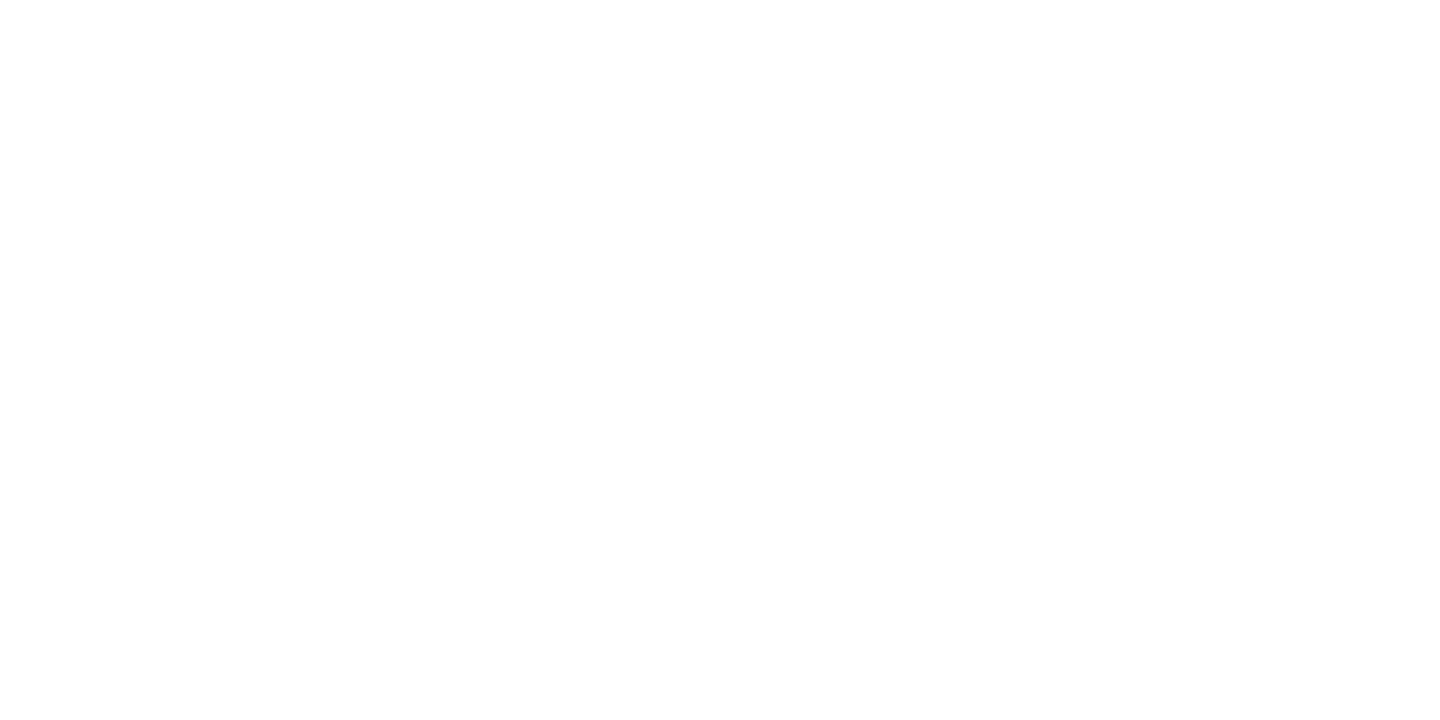

<IPython.core.display.Javascript object>


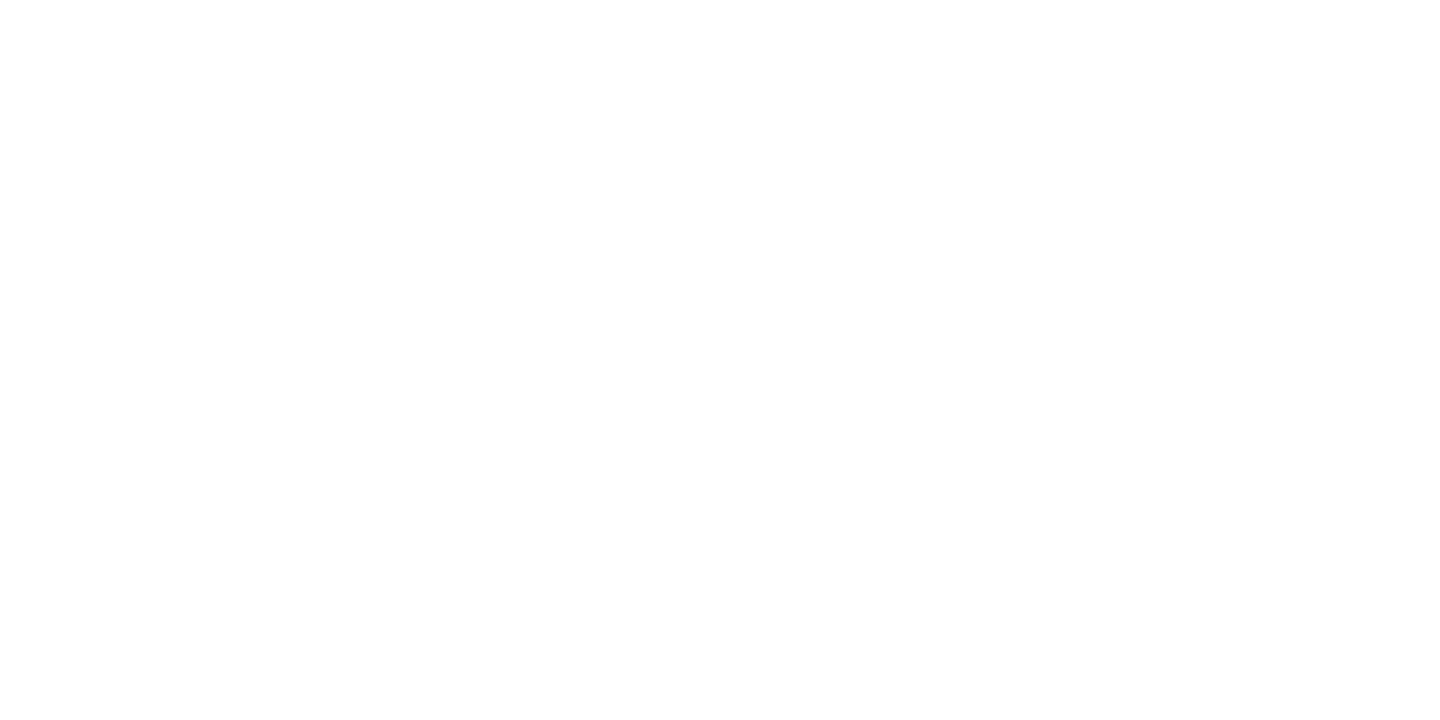

Traceback (most recent call last):
  File "/Users/hayk/anaconda/envs/py36/lib/python3.6/site-packages/matplotlib/cbook/__init__.py", line 388, in process
    proxy(*args, **kwargs)
  File "/Users/hayk/anaconda/envs/py36/lib/python3.6/site-packages/matplotlib/cbook/__init__.py", line 228, in __call__
    return mtd(*args, **kwargs)
  File "/Users/hayk/anaconda/envs/py36/lib/python3.6/site-packages/matplotlib/animation.py", line 1499, in _stop
    self.event_source.remove_callback(self._loop_delay)
AttributeError: 'NoneType' object has no attribute 'remove_callback'


In [248]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation, rc
from __future__ import unicode_literals
from matplotlib.patches import Circle
from IPython.display import HTML, Image
rc('font', **{'family': 'serif', 'serif': ['Helvetica'], 'size': 10})
rc('text.latex',unicode=True)
rc('text.latex',preamble=r'\usepackage[utf8]{inputenc}')
rc('text.latex',preamble=r'\usepackage[russian]{babel}')
matplotlib.rcParams['text.latex.unicode'] = True
%matplotlib notebook

v = 100.
cmap = plt.cm.plasma
times = np.linspace(0, 1, 10)

def circle(ax, x, y, radius=0.15, color='k', ls='-'):
    circle = Circle((x, y), radius, clip_on=False, zorder=10, linewidth=.5, linestyle=ls)
    ax.add_artist(circle)
    return circle

fig, ax = plt.subplots(figsize=(10,5))
ax.axis('off')
ax.set_xlim(-150, 20)
ax.set_ylim(-50, 50)
ax.set_aspect(1)
# plt.tight_layout()
ax.plot([-150, 50], [0, 0], c='k', ls='--', lw=1, alpha=0.3)
title = ax.set_title('blabla',fontsize=20)
# ax.set_title(r'$v_{\textrm{ф}}$' + r'$={{{:.1f}}}~v$'.format(1/alpha) + r'~~~$v_{\textrm{гр}}$' + r'$={{{:.1f}}}~v$'.format(0.5/alpha), fontsize=20)
pnt = ax.scatter(-10000, 0, c=cmap(255), zorder=10, s=30)
pnts = []
circles1 = []
lines1 = []
lines2 = []
pnts2 = []
# circles2 = []
for tm in times:
    pnts.append(plt.scatter(-10000, 0, zorder=10, s=30))
    circ = circle(ax, 0, 0, radius=0, ls='--')
    circ.set_visible(False)
    circles1.append(circ)
    ln1, = ax.plot([], [], c='red', lw=0.6)
    ln2, = ax.plot([], [], c='red', lw=0.6)
    lines1.append(ln1)
    lines2.append(ln2)
    pnts2.append(plt.scatter(-10000, 0, zorder=10, s=20))
#     circ = circle(ax, 0, 0, radius=0)
#     circ.set_visible(False)
#     circles2.append(circ)

line1, = ax.plot([], [], c='red', lw=0.6, ls=':')
line2, = ax.plot([], [], c='red', lw=0.6, ls=':')
text1 = ax.text(-1000, -1000, '')
text2 = ax.text(-1000, -1000, '')
line3, = ax.plot([], [], c='red', lw=0.6)
    
def animate(i):
    time = 1
    alpha = 1 / i
    vph = v / alpha
    vgr = vph / 2.
    title.set_text(r'$v_{\textrm{ф}}$' + r'$={{{:.2f}}}~v$'.format(1/alpha) + r'~~~$v_{\textrm{гр}}$' + r'$={{{:.2f}}}~v$'.format(0.5/alpha))
    pnt.set_offsets(np.c_[-120 + v * time, 0])
    # phase front
    t = (time - times[0])
    x1 = -120. + v * time
    x2 = -120. + v * time - v * t + vph**2 * t / v
    y1 = 0.
    y2 = (vph / v) * np.sqrt(v**2 - vph**2) * t
    line1.set_xdata([x1, x2])
    line1.set_ydata([y1, y2])
    line2.set_xdata([x1, x2])
    line2.set_ydata([-y1, -y2])
    for i in range(len(times)):
        if time > times[i]:
            x0 = -120. + v * times[i]
            y0 = 0.
            col0 = cmap(1 - time + times[i])
            # point
            pnts[i].set_facecolors(col0)
            pnts[i].set_offsets(np.c_[x0, y0])
            # circles
            circles1[i].center = x0, y0
            circles1[i].radius = vph * (time - times[i])
            col = list(col0)
            col[-1] = 1 - np.tanh(2 * (time - times[i]))
            col = tuple(col)
            circles1[i].set_edgecolor(col)
            circles1[i].set_facecolor((0,0,0,0))
            circles1[i].set_visible(True)
            # lines to front
            col = list(col0)
            col[-1] = 1 - np.tanh(2 * (time - times[i]))
            col = tuple(col)
            x3 = (x0*(x1 - x2)**2 + (x2*(-y0 + y1) + x1*(y0 - y2))*(y1 - y2))/(x1**2 - 2*x1*x2 + x2**2 + (y1 - y2)**2)
            y3 = (x2**2*y1 + y0*y1**2 + x0*(x1 - x2)*(y1 - y2) + x1**2*y2 - 2*y0*y1*y2 + y0*y2**2 - x1*x2*(y1 + y2))/(x1**2 - 2*x1*x2 + x2**2 + (y1 - y2)**2)
            lines1[i].set_xdata([x0, x3])
            lines1[i].set_ydata([y0, y3])
            lines1[i].set_color(col)
            lines2[i].set_xdata([x0, x3])
            lines2[i].set_ydata([y0, -y3])
            lines2[i].set_color(col)
            col = list(col0)
            col[-1] = 1 - np.tanh((time - times[i]))
            col = tuple(col)
            pnts2[i].set_offsets(np.c_[0.5 * (x0 + x3), 0.5 * (y0 + y3)])
            pnts2[i].set_facecolors(col)
    x0 = -120.
    y0 = 0.
    x3 = (x0*(x1 - x2)**2 + (x2*(-y0 + y1) + x1*(y0 - y2))*(y1 - y2))/(x1**2 - 2*x1*x2 + x2**2 + (y1 - y2)**2)
    y3 = (x2**2*y1 + y0*y1**2 + x0*(x1 - x2)*(y1 - y2) + x1**2*y2 - 2*y0*y1*y2 + y0*y2**2 - x1*x2*(y1 + y2))/(x1**2 - 2*x1*x2 + x2**2 + (y1 - y2)**2)
    x2, y2 = (0.5 * (x0 + x3), 0.5 * (y0 + y3))
    line3.set_xdata([x1, x2])
    line3.set_ydata([y1, y2])

factor = 3
anim = animation.FuncAnimation(fig, animate, np.concatenate([np.linspace(0.01, 0.99, 300 / factor), np.linspace(0.01, 0.99, 300 / factor)[::-1]]), 
                               interval=1, repeat=False)
anim.save('/Users/hayk/Desktop/anim3.gif', writer='imagemagick', fps = 60 / factor, dpi=150)
# anim = animation.FuncAnimation(fig, animate, np.arange(0,100,2), interval=1, repeat=False)
# anim.save('/Users/hayk/Desktop/animation.gif', writer='imagemagick', fps=30)

<IPython.core.display.Javascript object>


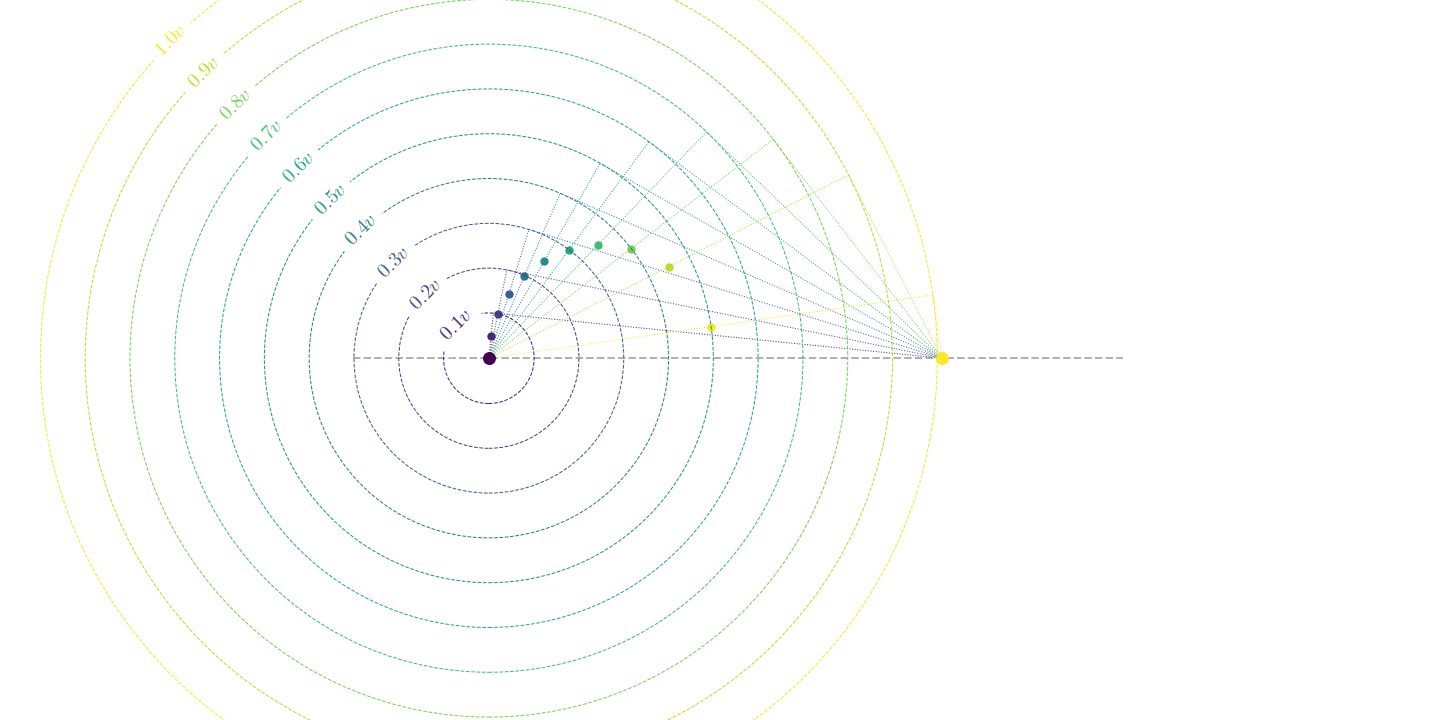

In [290]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation, rc
from __future__ import unicode_literals
from matplotlib.patches import Circle
from IPython.display import HTML, Image
rc('font', **{'family': 'serif', 'serif': ['Helvetica'], 'size': 10})
rc('text.latex',unicode=True)
rc('text.latex',preamble=r'\usepackage[utf8]{inputenc}')
rc('text.latex',preamble=r'\usepackage[russian]{babel}')
matplotlib.rcParams['text.latex.unicode'] = True
%matplotlib notebook

v = 100.
cmap = plt.cm.viridis
times = np.linspace(0, 1, 10)

def circle(ax, x, y, radius=0.15, color='k', ls='-'):
    circle = Circle((x, y), radius, clip_on=False, zorder=10, 
                    linewidth=.5, linestyle=ls, facecolor=(0,0,0,0), edgecolor=color)
    ax.add_artist(circle)
    return circle

fig, ax = plt.subplots(figsize=(10,5))
ax.axis('off')
ax.set_xlim(-150, 20)
ax.set_ylim(-60, 60)
ax.set_aspect(1)
# plt.tight_layout()
ax.plot([-150, 50], [0, 0], c='k', ls='--', lw=1, alpha=0.3)

xc, yc = (-120, 0)
x0, y0 = (-120 + v, 0)
ax.scatter(xc, yc, c=cmap(0), zorder=10, s=30)
ax.scatter(x0, y0, c=cmap(255), zorder=10, s=30)

for i in np.linspace(0.1, 0.99, 10):
    vph = v * i
    rad = vph * time
    circle(ax, xc, yc, radius = rad, color=cmap(i), ls='--')
    dd = x0 - xc
    y1 = rad * np.sqrt(dd**2 - rad**2) / dd
    x1 = xc + np.sqrt(rad**2 - y1**2)
#     ax.scatter(x1, y1, c=cmap(i), s=10)
    ax.plot([xc, x1], [yc, y1], lw=0.5, ls=':', c=cmap(i))
    ax.plot([x1, x0], [y1, y0], lw=0.5, ls=':', c=cmap(i))
    ax.scatter((x1 + xc)*0.5, (y1 + yc)*0.5, c=cmap(i), s=10)
    phi = np.pi / 2 + np.pi / 4.
    ax.text(xc + np.cos(phi) * rad, yc + np.sin(phi) * rad, r'${{{:.1f}}}v$'.format(i), 
            va='center', ha='center', rotation=45, color=cmap(i), 
            bbox = dict(facecolor='white', alpha=1, edgecolor='white'), zorder = 11)

plt.savefig('/Users/hayk/Desktop/pic3.png', dpi=300)

<IPython.core.display.Javascript object>


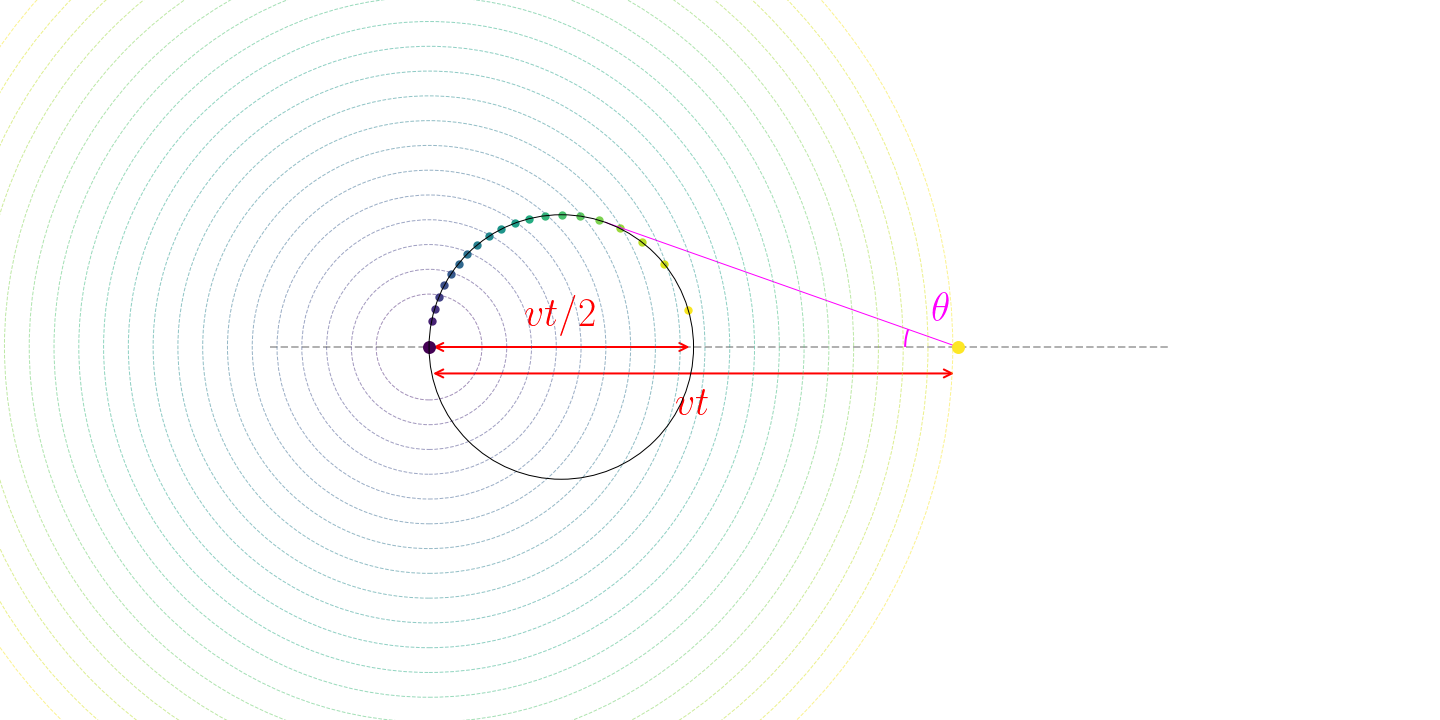

In [356]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation, rc
from __future__ import unicode_literals
from matplotlib.patches import Circle, Arc
from IPython.display import HTML, Image
rc('font', **{'family': 'serif', 'serif': ['Helvetica'], 'size': 10})
rc('text.latex',unicode=True)
rc('text.latex',preamble=r'\usepackage[utf8]{inputenc}')
rc('text.latex',preamble=r'\usepackage[russian]{babel}')
matplotlib.rcParams['text.latex.unicode'] = True
%matplotlib notebook

v = 100.
cmap = plt.cm.viridis
times = np.linspace(0, 1, 10)

def circle(ax, x, y, radius=0.15, color='k', ls='-'):
    circle = Circle((x, y), radius, clip_on=False, zorder=10, 
                    linewidth=.5, linestyle=ls, facecolor=(0,0,0,0), edgecolor=color)
    ax.add_artist(circle)
    return circle

fig, ax = plt.subplots(figsize=(10,5))
ax.axis('off')
ax.set_xlim(-150, 20)
ax.set_ylim(-60, 60)
ax.set_aspect(1)
# plt.tight_layout()
ax.plot([-150, 50], [0, 0], c='k', ls='--', lw=1, alpha=0.3)

xc, yc = (-120, 0)
x0, y0 = (-120 + v, 0)
ax.scatter(xc, yc, c=cmap(0), zorder=10, s=30)
ax.scatter(x0, y0, c=cmap(255), zorder=10, s=30)

for i in np.linspace(0.1, 0.99, 20):
    vph = v * i
    rad = vph * time
    col_1 = list(cmap(i))
    col_1[-1] = 0.5
    circle(ax, xc, yc, radius = rad, color=col_1, ls='--')
    dd = x0 - xc
    y1 = rad * np.sqrt(dd**2 - rad**2) / dd
    x1 = xc + np.sqrt(rad**2 - y1**2)
#     ax.scatter(x1, y1, c=cmap(i), s=10)
#     ax.plot([xc, x1], [yc, y1], lw=0.5, ls=':', c=cmap(i))
#     ax.plot([x1, x0], [y1, y0], lw=0.5, ls=':', c=cmap(i))
    ax.scatter((x1 + xc)*0.5, (y1 + yc)*0.5, c=cmap(i), s=10)
    phi = np.pi / 2 + np.pi / 4.

circle(ax, xc + (x0 - xc) * 0.25, yc + (y0 - yc) * 0.25, radius = (x0 - xc) * 0.25, color='k')
ax.annotate(s='', xy=(xc,yc - 5), xytext=(x0,y0 - 5), arrowprops=dict(arrowstyle='<->', edgecolor='red'))
ax.text((x0 + xc) * 0.5, -7, r'$vt$', fontsize=20, color='red', ha='center', va='top')
ax.annotate(s='', xy=(xc,yc), xytext=((xc + x0)*0.5,y0), arrowprops=dict(arrowstyle='<->', edgecolor='red'))
ax.text(xc + (x0 - xc) * 0.25, 2, r'$vt/2$', fontsize=20, color='red', ha='center', va='bottom')
plt.tight_layout()
#     ax.text(xc + np.cos(phi) * rad, yc + np.sin(phi) * rad, r'${{{:.1f}}}v$'.format(i), 
#             va='center', ha='center', rotation=45, color=cmap(i), 
#             bbox = dict(facecolor='white', alpha=1, edgecolor='white'), zorder = 11)
rad = (x0 - xc) * 0.25
dd = x0 - (xc + (x0 - xc) * 0.25)
y1 = rad * np.sqrt(dd**2 - rad**2) / dd
x1 = xc + (x0 - xc) * 0.25 + np.sqrt(rad**2 - y1**2)
theta = np.arctan((y1 - y0) / (x1 - x0)) * 180 / np.pi
ax.plot([x0, x1], [y0, y1], lw=0.5, c='magenta')
ax.text(x0-5, y0+5, r'$\theta$', fontsize=20, color='magenta')
ax.add_patch(Arc((x0, y0), 20, 20, 
                 theta1=180 + theta, theta2=180.0, edgecolor='magenta'))

plt.savefig('/Users/hayk/Desktop/pic4.png', dpi=300)

In [376]:
import astropy.units as u_
import astropy.constants as c_
import numpy as np

L = 20 * u_.cm
U = .5 * u_.m / u_.s

Fr = (U / np.sqrt(c_.g0 * L)).cgs
Fr

<Quantity 0.35702175>